In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [49]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning - 1/economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [50]:
#we see an unnammed column, that we will be droping it
df.drop(columns=["Unnamed: 0","year","month"], axis=1,inplace=True)

In [51]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [52]:
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


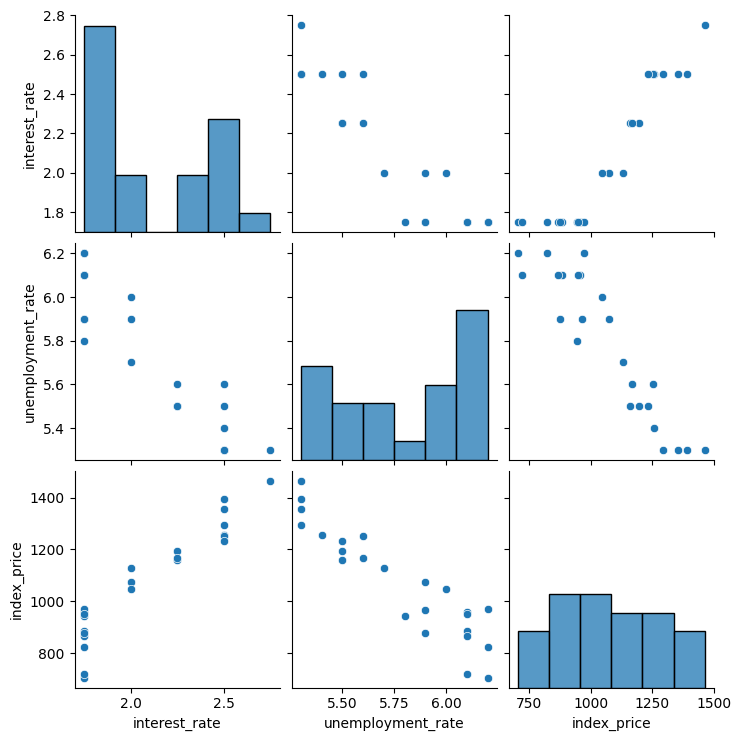

In [53]:
sns.pairplot(df)

In [54]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


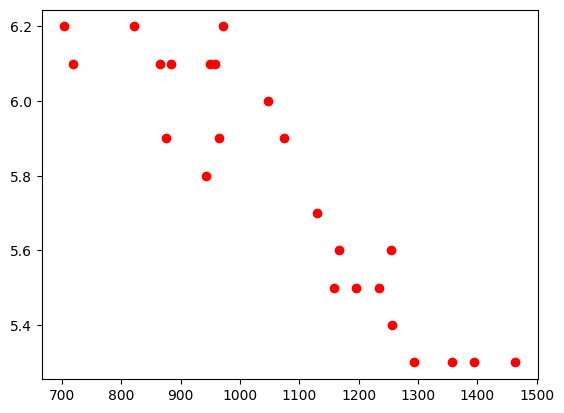

In [55]:
plt.scatter(df['index_price'],df['unemployment_rate'],color="r")

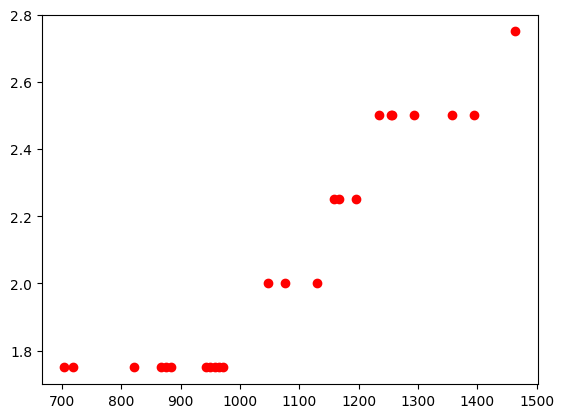

In [56]:
plt.scatter(df['index_price'],df['interest_rate'],color="r")

In [57]:
# separating independent and dependent features
X=df[["interest_rate","unemployment_rate"]]
y=df["index_price"]

In [58]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [59]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [60]:
# separating into train and test split data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=2)


<Axes: xlabel='interest_rate', ylabel='index_price'>

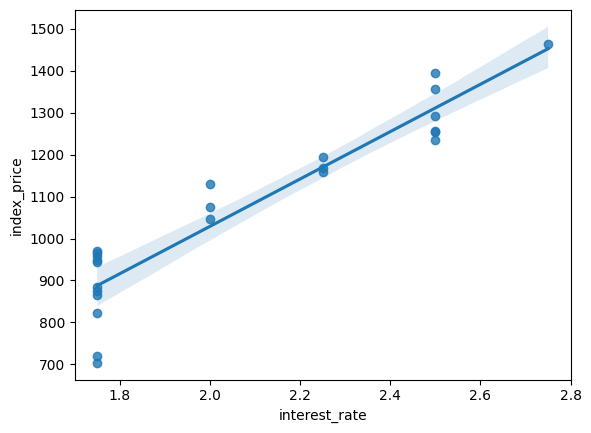

In [61]:
sns.regplot(x=df["interest_rate"], y=df["index_price"])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

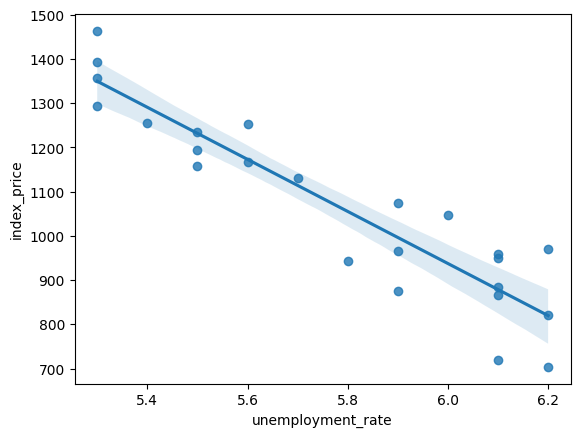

In [62]:
sns.regplot(x=df["unemployment_rate"], y=df["index_price"])

In [63]:
# stardard scaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [64]:
regressor=LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [65]:

from sklearn.model_selection import cross_val_score

In [66]:
validataion_score=cross_val_score(regressor,X_train,y_train,scoring="neg_mean_squared_error",cv=5)

In [67]:
validataion_score

array([ -3219.88994565,  -4783.83416631,  -1970.03917633, -13728.2342217 ,
        -3612.56970351])

In [68]:
np.mean(validataion_score)

np.float64(-5462.91344269871)

In [69]:
#prediction
y_pred=regressor.predict(X_test)

In [70]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [71]:
print(mse)
print(mae)
print(r2)

7401.026992298733
69.89796329905221
0.8862162361408252


Text(0, 0.5, 'y_pred')

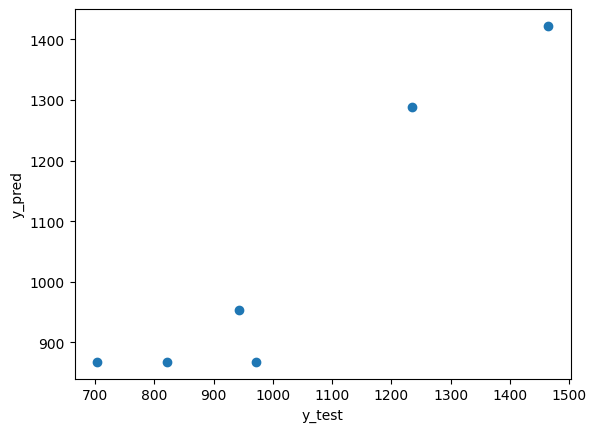

In [72]:
#asssumptions
plt.scatter(y_test,y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")
#

In [73]:
residuals=y_test-y_pred
print(residuals)

21    -45.634604
0      41.638234
22   -163.634604
6     -55.021174
14    -10.093769
16    103.365396
Name: index_price, dtype: float64


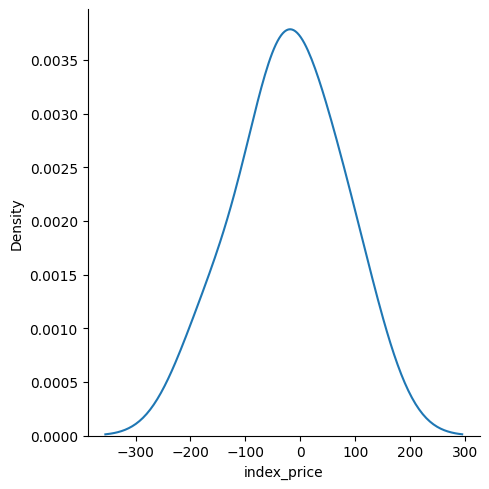

In [74]:
## plot
sns.displot(residuals, kind="kde")

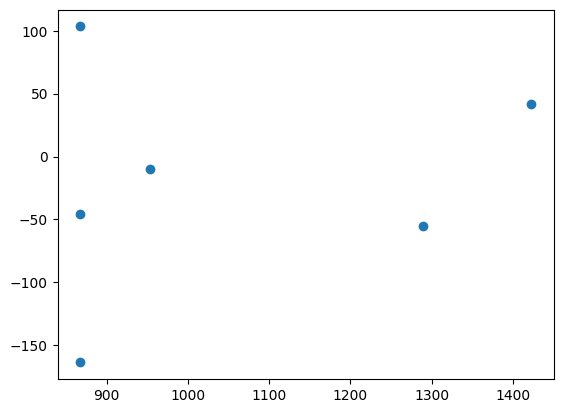

In [75]:
## scater plot wit repect to prediction and residuals
plt.scatter(y_pred, residuals)

In [76]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [77]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):             -0.097
Method:                 Least Squares   F-statistic:                             0.2073
Date:                Sun, 17 May 2026   Prob (F-statistic):                       0.815
Time:                        10:49:31   Log-Likelihood:                         -151.39
No. Observations:                  18   AIC:                                      306.8
Df Residuals:                      16   BIC:                                      308.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           113.0118    785.827      0.144      0.887   -1552.867    1778.890
x2           -64.5761    785.827     -0.082      0.936   -1730.455    1601.302
==============================================================================
Omnibus:                        8.155   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.017   Jarque-Bera (JB):                5.174
Skew:                          -1.108   Prob(JB):                       0.0752
Kurtosis:                       4.411   Cond. No.                         5.60
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [80]:
print(regressor.coef_)

[113.01178532 -64.57612859]
